In [3]:
from teachgrav.laws import flat_law, law
from teachgrav.gp import GPModel
from teachgrav.scenarios import ScenarioFactory
import matplotlib.pyplot as plt
import numpy as np

In [4]:
factory = ScenarioFactory('jax-metal')
model = GPModel(factory)


In [5]:
model.train(1024, n_bodies=2, fixed_masses=[1.0, 1.0])


In [6]:
masses = factory.engine.np.array([1.0, 1.0])
immobile = factory.engine.np.array([False, False])


In [7]:
scenario = factory.create_scenario('scatter', n_bodies=2,
                                    fixed_masses=masses)
gp_res = model.gp_law(scenario)
res = law(scenario)
print("GP result:\n", gp_res)
print("True result:\n", res)
assert gp_res.shape == res.shape

Scales: X mean: [-0.01710725 -0.02741853  0.01710725  0.02741853 -0.01662151 -0.01083746
  0.01662151  0.01083746] X std: [0.41911718 0.41329342 0.41911718 0.41329342 0.4204161  0.40415904
 0.4204161  0.40415904]
Scales: Y mean: [-2.0096478  1.079977   2.0096478 -1.079977 ] Y std: [36.0603   31.828205 36.0603   31.828205]
GP predicted accelerations: [-2.0096478  1.079977   2.0096478 -1.079977 ]
Current velocities: [ 0.37923968 -0.07582378 -0.37923968  0.07582378]
GP result:
 [[[ 0.37923968 -0.07582378]
  [-0.37923968  0.07582378]]

 [[-2.0096478   1.079977  ]
  [ 2.0096478  -1.079977  ]]]
True result:
 [[[ 0.37923968 -0.07582378]
  [-0.37923968  0.07582378]]

 [[-0.23142552  0.09775878]
  [ 0.23142552 -0.09775878]]]


In [8]:
def plot(ranges, fn, np=np):

    x = np.linspace(ranges[0][0], ranges[0][1], 200)
    y = np.linspace(ranges[1][0], ranges[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = fn(X, Y)
    plt.style.use("dark_background")

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_zlabel("$f(x, y)$")
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

    plt.show()

In [9]:
# Show some partial cuts across the data

# The law, for fixed x0, y0, vx0, vy0, vx1, vy1, as a function of x1, y1,
# shwoing the acceeration of body 0 in the x direction.
def cut(x1, y1):
    x1f = x1.flatten()
    y1f = y1.flatten()
    z = factory.engine.np.zeros(x1f.shape)
    ICs = factory.engine.np.stack([z, z, x1f, y1f, z, z, z, z],axis=1)
    print("ICs shape:", ICs.shape)
    result = flat_law(ICs, masses, immobile).reshape(len(x1f), 2, 2, 2)
    return result[:,1, 0, 0].reshape(x1.shape) # x accelerations of body 0
cut(factory.engine.np.array([[0, 0],[1,1]]),factory.engine.np.array([[0, 1],[0,1]]))

ICs shape: (4, 8)


Array([[0.       , 0.       ],
       [1.       , 0.3535534]], dtype=float32)

ICs shape: (40000, 8)


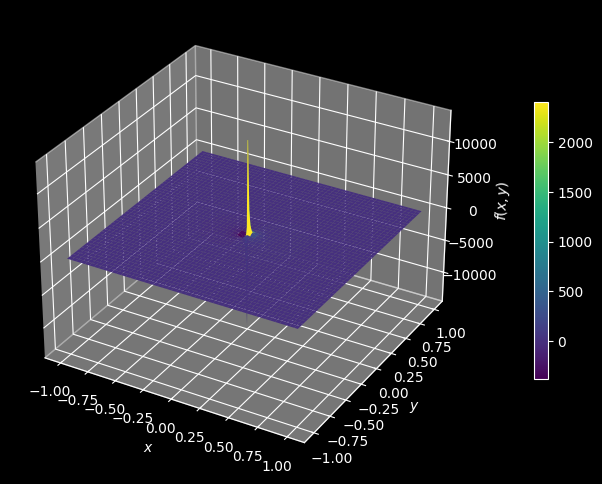

In [10]:
plot([[-1, 1], [-1, 1]], cut, np=factory.engine.np)

In [11]:
def cut(x1, y1):
    x1f = x1.flatten()
    y1f = y1.flatten()
    z = factory.engine.np.zeros(x1f.shape)
    ICs = factory.engine.np.stack([z, z, x1f, y1f, z, z, z, z],axis=1)
    result = model.gp_flat_law(ICs, masses, immobile)
    result = result.reshape(len(x1f), 2, 2, 2)
    return result[:,1, 0, 0].reshape(x1.shape) # x accelerations of body 0
cut(factory.engine.np.array([[0, 0],[1,1]]),factory.engine.np.array([[0, 1],[0,1]]))

Array([[-2.251719 , -2.0096478],
       [-2.0096478, -2.0096478]], dtype=float32)

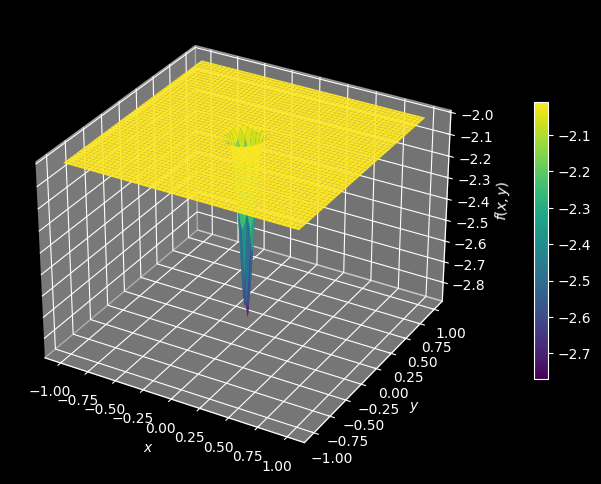

In [12]:
plot([[-1, 1], [-1, 1]], cut, np=factory.engine.np)